In [1]:
pip install cartopy

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install netCDF4

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the dataset
dataset = xr.open_dataset('air.2m.mon.mean.nc')
print(dataset)  # Check the contents of the dataset




<xarray.Dataset>
Dimensions:  (lat: 94, lon: 192, time: 924)
Coordinates:
  * lat      (lat) float32 88.54 86.65 84.75 82.85 ... -84.75 -86.65 -88.54
  * lon      (lon) float32 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
  * time     (time) datetime64[ns] 1948-01-01 1948-02-01 ... 2024-12-01
Data variables:
    air      (time, lat, lon) float32 ...
Attributes:
    Conventions:    COARDS
    description:    Data is from NMC initialized reanalysis\n(4x/day).  It co...
    platform:       Model
    NCO:            20121012
    history:        created 97/10/04 by Hoop (netCDF2.3)\nConverted to chunke...
    title:          monthly mean air.2m from the NCEP Reanalysis
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...


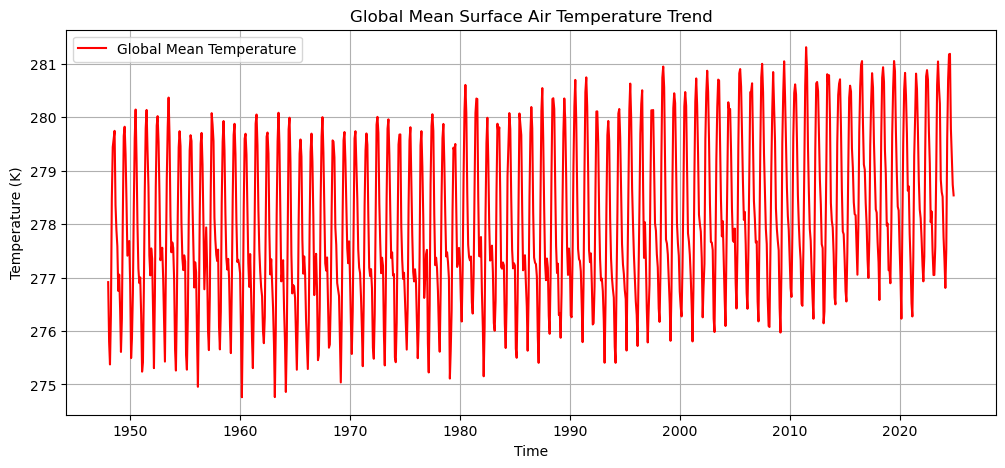

In [12]:
air_temp = dataset['air']  # Air temperature variable
time = air_temp['time']

# Compute global mean temperature
global_mean_temp = air_temp.mean(dim=['lat', 'lon'])

# Plot global mean temperature trend
plt.figure(figsize=(12, 5))
plt.plot(time, global_mean_temp, label='Global Mean Temperature', color='r')
plt.xlabel('Time')
plt.ylabel('Temperature (K)')
plt.title('Global Mean Surface Air Temperature Trend')
plt.legend()
plt.grid()
plt.show()

In [4]:
# Standardization (Z-score normalization for each month separately)
climatology_mean = air_temp.groupby('time.month').mean('time')
climatology_std = air_temp.groupby('time.month').std('time')
standardized_air_temp = (air_temp.groupby('time.month') - climatology_mean) / climatology_std



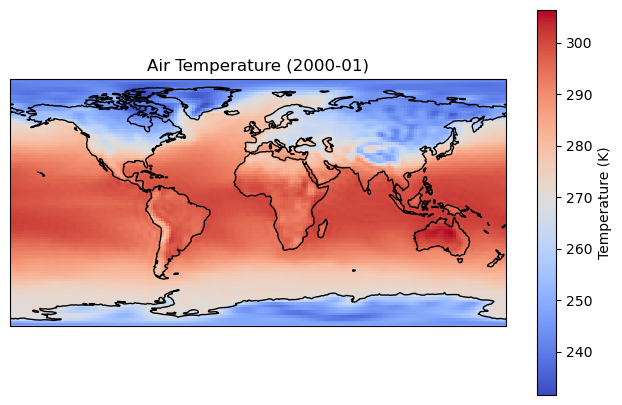

In [11]:
# Select a year and month for visualization
year_selected = 2000
month_selected = 1  # January
date_selected = f'{year_selected}-{month_selected:02d}'

temp_selected = air_temp.sel(time=date_selected)


# Plot spatial distribution of air temperature
fig, ax = plt.subplots(
    figsize=(8, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Air Temperature Plot
ax.set_title(f'Air Temperature ({date_selected})')
ax.coastlines()
temp_plot = ax.pcolormesh(temp_selected.lon, temp_selected.lat, temp_selected.squeeze(),
                             transform=ccrs.PlateCarree(), cmap='coolwarm', shading="auto")
fig.colorbar(temp_plot, ax=ax, orientation='vertical', label='Temperature (K)')


plt.show()


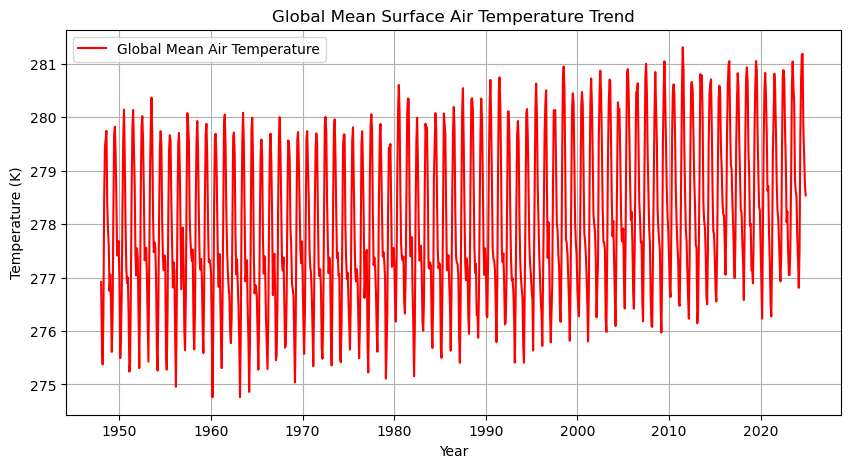

ValueError: For X (193) and Y (95) with flat shading, A should have shape (94, 192, 3) or (94, 192, 4) or (94, 192) or (18048,), not (94, 192, 12)

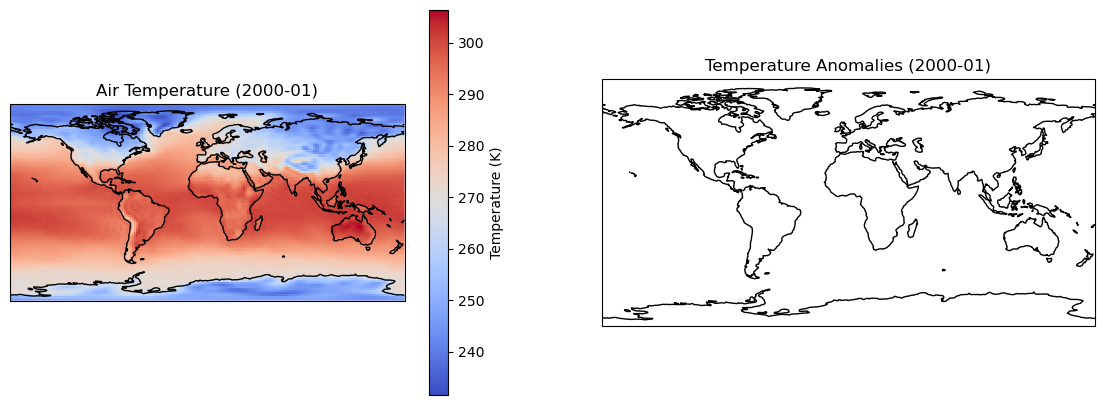

In [28]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the dataset
dataset = xr.open_dataset('air.2m.mon.mean.nc', engine='netcdf4')
air_temp = dataset['air']  # Air temperature variable
time = air_temp['time']

# Compute Global Mean Temperature
global_mean_temp = air_temp.mean(dim=['lat', 'lon'])

# Plot Global Mean Temperature Trend
plt.figure(figsize=(10, 5))
plt.plot(time, global_mean_temp, label='Global Mean Air Temperature', color='r')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.title('Global Mean Surface Air Temperature Trend')
plt.legend()
plt.grid()
plt.show()

# Standardize Data
climatology = air_temp.groupby('time.month').mean('time')
std_dev = air_temp.groupby('time.month').std('time')
anomalies = (air_temp.groupby('time.month') - climatology) / std_dev

# Select a specific year and month
year_selected = 2000
month_selected = 1
date_selected = f"{year_selected}-{month_selected:02d}"
temp_selected = air_temp.sel(time=f"{year_selected}-{month_selected:02d}")
anomaly_selected = anomalies.sel(time=f"{year_selected}-{month_selected:02d}")

# Plot Temperature and Anomalies
fig, ax = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Air Temperature Plot
ax[0].set_title(f'Air Temperature ({date_selected})')
ax[0].coastlines()
temp_plot = ax[0].pcolormesh(temp_selected.lon, temp_selected.lat, temp_selected.squeeze(),
                             transform=ccrs.PlateCarree(), cmap='coolwarm', shading="auto")
fig.colorbar(temp_plot, ax=ax[0], orientation='vertical', label='Temperature (K)')

# Anomaly Plot
ax[1].set_title(f'Temperature Anomalies ({date_selected})')
ax[1].coastlines()
anomaly_plot = ax[1].pcolormesh(anomaly_selected.lon, anomaly_selected.lat, anomaly_selected.isel(time=0).squeeze(),
                                transform=ccrs.PlateCarree(), cmap='RdBu_r', shading="auto")

fig.colorbar(anomaly_plot, ax=ax[1], orientation='vertical', label='Standardized Anomaly')

plt.show()


In [24]:
print(anomaly_selected.dims)
print(anomaly_selected.shape)


('time', 'lat', 'lon', 'month')
(1, 94, 192, 12)


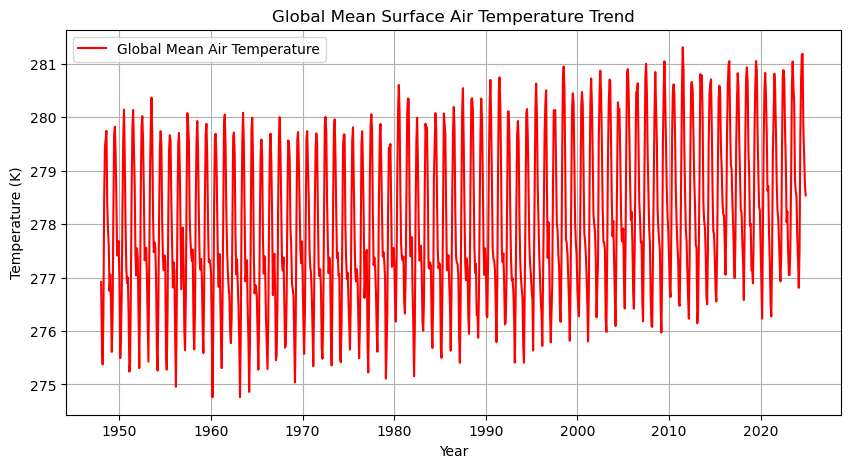

(94, 192, 12)


ValueError: For X (193) and Y (95) with flat shading, A should have shape (94, 192, 3) or (94, 192, 4) or (94, 192) or (18048,), not (94, 192, 12)

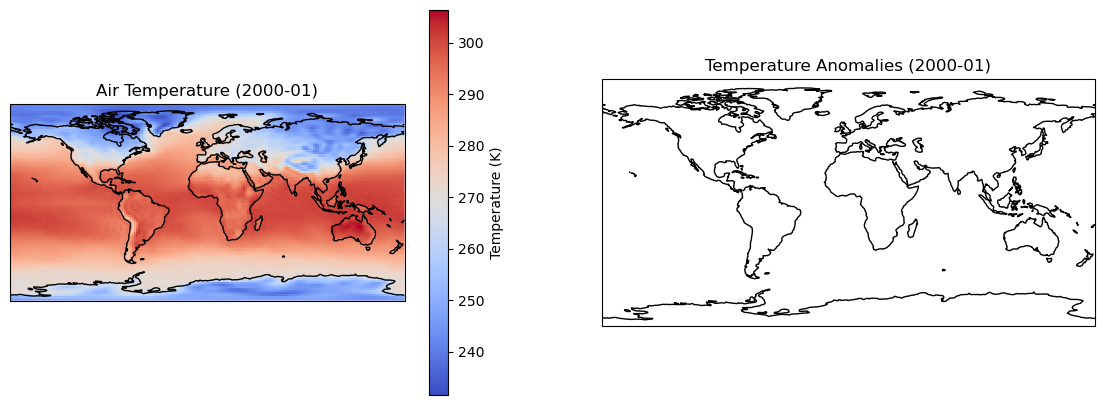

In [32]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the dataset
dataset = xr.open_dataset('air.2m.mon.mean.nc', engine='netcdf4')
air_temp = dataset['air']  # Air temperature variable
time = air_temp['time']

# Compute Global Mean Temperature
global_mean_temp = air_temp.mean(dim=['lat', 'lon'])

# Plot Global Mean Temperature Trend
plt.figure(figsize=(10, 5))
plt.plot(time, global_mean_temp, label='Global Mean Air Temperature', color='r')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')
plt.title('Global Mean Surface Air Temperature Trend')
plt.legend()
plt.grid()
plt.show()

# Standardize Data
climatology = air_temp.groupby('time.month').mean('time')
std_dev = air_temp.groupby('time.month').std('time')
anomalies = (air_temp.groupby('time.month') - climatology) / std_dev

# Select a specific year and month
year_selected = 2000
month_selected = 1
date_selected = f"{year_selected}-{month_selected:02d}"
temp_selected = air_temp.sel(time=f"{year_selected}-{month_selected:02d}")

# Select the anomaly for the specific year and month
anomaly_selected = anomalies.sel(time=f"{year_selected}-{month_selected:02d}")

# Drop the time and month dimensions (if they exist)
anomaly_selected = anomaly_selected.squeeze(drop=True)

# Verify the shape of anomaly_selected
print(anomaly_selected.shape)  # Should be (lat, lon)

# Plot Temperature and Anomalies
fig, ax = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Air Temperature Plot
ax[0].set_title(f'Air Temperature ({date_selected})')
ax[0].coastlines()
temp_plot = ax[0].pcolormesh(temp_selected.lon, temp_selected.lat, temp_selected.squeeze(),
                             transform=ccrs.PlateCarree(), cmap='coolwarm', shading="auto")
fig.colorbar(temp_plot, ax=ax[0], orientation='vertical', label='Temperature (K)')

# Anomaly Plot
ax[1].set_title(f'Temperature Anomalies ({date_selected})')
ax[1].coastlines()
anomaly_plot = ax[1].pcolormesh(anomaly_selected.lon, anomaly_selected.lat, anomaly_selected,
                                transform=ccrs.PlateCarree(), cmap='RdBu_r', shading="auto")
fig.colorbar(anomaly_plot, ax=ax[1], orientation='vertical', label='Standardized Anomaly')

plt.show()